In [1]:
!mkdir -p churnlens data/raw data/processed models exports
!wget -q -O data/raw/Telco-Customer-Churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
!wc -l data/raw/Telco-Customer-Churn.csv

open("churnlens/__init__.py", "w").write('"""ChurnLens: customer-churn analytics (ETL -> SQL -> ML)."""\n__version__ = "0.1.0"\n')
open("churnlens/config.py", "w").write('''"""Central paths and constants."""
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1]
RAW_CSV = ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"
DB_PATH = ROOT / "data" / "processed" / "churnlens.db"
MODEL_PATH = ROOT / "models" / "churn_model.joblib"
METRICS_PATH = ROOT / "models" / "metrics.json"
EXPORT_PATH = ROOT / "exports" / "customers_for_powerbi.csv"
SEED = 42
''')

7044 data/raw/Telco-Customer-Churn.csv


391

In [2]:
%%writefile churnlens/algorithms.py
"""Small data-structure and algorithm building blocks used by the project (and unit-tested).

- ``TopK``: a bounded min-heap that keeps the k highest-scoring items in O(n log k) time and O(k) memory.
- ``bucketize``: maps a number to a labelled range with binary search (bisect), O(log b).
"""
import heapq
from bisect import bisect_left
from collections.abc import Iterable, Sequence
from itertools import count
from typing import Any


class TopK:
    """Keep the ``k`` items with the highest scores while streaming through the data once."""

    def __init__(self, k: int):
        if k <= 0:
            raise ValueError("k must be positive")
        self.k = k
        self._heap: list[tuple[float, int, Any]] = []   # min-heap: the smallest kept score sits at index 0
        self._tie = count()                              # tie-breaker so items themselves are never compared

    def push(self, score: float, item: Any) -> None:
        entry = (score, next(self._tie), item)
        if len(self._heap) < self.k:
            heapq.heappush(self._heap, entry)
        elif score > self._heap[0][0]:
            heapq.heapreplace(self._heap, entry)

    def extend(self, pairs: Iterable[tuple[float, Any]]) -> "TopK":
        for score, item in pairs:
            self.push(score, item)
        return self

    def items(self) -> list[tuple[float, Any]]:
        """Highest score first."""
        return [(s, it) for s, _, it in sorted(self._heap, key=lambda e: (-e[0], e[1]))]

    def __len__(self) -> int:
        return len(self._heap)


def bucketize(value: float, upper_bounds: Sequence[float], labels: Sequence[str]) -> str:
    """Return the label of the first range whose (inclusive) upper bound is >= value.

    ``upper_bounds`` must be sorted ascending and ``labels`` must have one more entry than ``upper_bounds``
    (the last label catches everything above the final bound).
    """
    if len(labels) != len(upper_bounds) + 1:
        raise ValueError("labels must have exactly one more entry than upper_bounds")
    return labels[bisect_left(upper_bounds, value)]

Writing churnlens/algorithms.py


In [3]:
%%writefile churnlens/pipeline.py
"""Object-oriented ETL: extract the raw CSV, validate, clean and enrich it, and load it into SQLite."""
import sqlite3
import time
from dataclasses import dataclass, field
from pathlib import Path

import pandas as pd

from .algorithms import bucketize
from .config import DB_PATH, RAW_CSV

REQUIRED_COLUMNS = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn",
]
SERVICE_COLUMNS = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                   "TechSupport", "StreamingTV", "StreamingMovies"]
TENURE_BOUNDS = [12, 24, 48, 72]
TENURE_LABELS = ["0-12 months", "13-24 months", "25-48 months", "49-72 months", "73+ months"]


@dataclass
class ValidationReport:
    checks: list[dict] = field(default_factory=list)

    def add(self, name: str, passed: bool, detail: str = "") -> None:
        self.checks.append({"check": name, "passed": bool(passed), "detail": detail})

    @property
    def passed(self) -> bool:
        return all(c["passed"] for c in self.checks)

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.checks)


class DataValidator:
    """Data-quality gates. The pipeline stops if a check fails, instead of loading bad data."""

    def validate_raw(self, df: pd.DataFrame) -> ValidationReport:
        r = ValidationReport()
        missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
        r.add("required columns present", not missing, f"missing: {missing}" if missing else f"{len(REQUIRED_COLUMNS)} columns")
        r.add("has rows", len(df) > 0, f"{len(df)} rows")
        if missing:
            return r
        dup = int(df["customerID"].duplicated().sum())
        r.add("customerID is unique", dup == 0, f"{dup} duplicates")
        bad_churn = sorted(set(df["Churn"].dropna().astype(str).str.strip()) - {"Yes", "No"})
        r.add("Churn is Yes/No", not bad_churn, f"unexpected values: {bad_churn}" if bad_churn else "ok")
        r.add("tenure is non-negative", bool((df["tenure"] >= 0).all()), f"min={df['tenure'].min()}")
        r.add("MonthlyCharges is non-negative", bool((df["MonthlyCharges"] >= 0).all()), f"min={df['MonthlyCharges'].min()}")
        return r

    def validate_clean(self, df: pd.DataFrame) -> ValidationReport:
        r = ValidationReport()
        key_nulls = int(df[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]].isna().sum().sum())
        r.add("no nulls in key columns after cleaning", key_nulls == 0, f"{key_nulls} nulls")
        r.add("TotalCharges is numeric and non-negative", bool((df["TotalCharges"] >= 0).all()), f"min={df['TotalCharges'].min()}")
        r.add("churn_flag is 0/1", set(df["churn_flag"].unique()) <= {0, 1}, f"values={sorted(int(v) for v in df['churn_flag'].unique())}")
        r.add("tenure_bucket assigned to every row", bool(df["tenure_bucket"].notna().all()), "ok")
        return r


@dataclass
class ETLResult:
    rows_in: int
    rows_out: int
    raw_report: ValidationReport
    clean_report: ValidationReport
    seconds: dict
    db_path: Path


class ETLPipeline:
    """extract -> validate -> transform -> validate -> load. Mirrors the stages of a managed ETL job."""

    def __init__(self, raw_path: Path = RAW_CSV, db_path: Path = DB_PATH):
        self.raw_path = Path(raw_path)
        self.db_path = Path(db_path)
        self.validator = DataValidator()

    def extract(self) -> pd.DataFrame:
        return pd.read_csv(self.raw_path)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        for col in out.columns:                       # trim stray whitespace in text columns
            if pd.api.types.is_string_dtype(out[col]):
                out[col] = out[col].str.strip()
        # TotalCharges arrives as text; blanks belong to customers with tenure 0 (not billed yet)
        out["TotalCharges"] = pd.to_numeric(out["TotalCharges"], errors="coerce")
        new_customers = out["TotalCharges"].isna() & (out["tenure"] == 0)
        out.loc[new_customers, "TotalCharges"] = 0.0
        still_missing = out["TotalCharges"].isna()     # any other gap: estimate from tenure x monthly price
        out.loc[still_missing, "TotalCharges"] = out.loc[still_missing, "tenure"] * out.loc[still_missing, "MonthlyCharges"]
        out["churn_flag"] = (out["Churn"] == "Yes").astype(int)
        out["SeniorCitizen"] = out["SeniorCitizen"].astype(int)
        out["num_services"] = out[SERVICE_COLUMNS].isin(["Yes"]).sum(axis=1) + (out["InternetService"] != "No").astype(int)
        out["tenure_bucket"] = out["tenure"].map(lambda t: bucketize(t, TENURE_BOUNDS, TENURE_LABELS))
        return out

    def load(self, df: pd.DataFrame) -> None:
        self.db_path.parent.mkdir(parents=True, exist_ok=True)
        with sqlite3.connect(self.db_path) as con:
            df.to_sql("customers", con, if_exists="replace", index=False)
            con.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_customers_id ON customers(customerID)")
            con.execute("CREATE INDEX IF NOT EXISTS idx_customers_contract ON customers(Contract)")

    def run(self) -> ETLResult:
        timings: dict[str, float] = {}

        def timed(name, fn, *args):
            start = time.perf_counter()
            value = fn(*args)
            timings[name] = round(time.perf_counter() - start, 4)
            return value

        raw = timed("extract", self.extract)
        raw_report = self.validator.validate_raw(raw)
        if not raw_report.passed:
            raise ValueError(f"raw data failed validation:\n{raw_report.to_frame().to_string(index=False)}")
        clean = timed("transform", self.transform, raw)
        clean_report = self.validator.validate_clean(clean)
        if not clean_report.passed:
            raise ValueError(f"clean data failed validation:\n{clean_report.to_frame().to_string(index=False)}")
        timed("load", self.load, clean)
        return ETLResult(len(raw), len(clean), raw_report, clean_report, timings, self.db_path)

Writing churnlens/pipeline.py


In [4]:
%%writefile churnlens/sql.py
"""SQL analytics layer: a read-only repository plus named queries (joins, CTEs, window functions)."""
import sqlite3
from pathlib import Path

import pandas as pd

from .config import DB_PATH

QUERIES: dict[str, str] = {
    "kpis": """
        SELECT COUNT(*)                                        AS customers,
               ROUND(100.0 * AVG(churn_flag), 2)               AS churn_rate_pct,
               ROUND(AVG(MonthlyCharges), 2)                   AS avg_monthly_charge,
               ROUND(SUM(CASE WHEN churn_flag = 1 THEN MonthlyCharges END), 2) AS monthly_revenue_lost,
               ROUND(SUM(MonthlyCharges), 2)                   AS monthly_revenue_total
        FROM customers
    """,
    "churn_by_contract": """
        SELECT Contract,
               COUNT(*)                          AS customers,
               SUM(churn_flag)                   AS churned,
               ROUND(100.0 * AVG(churn_flag), 2) AS churn_rate_pct
        FROM customers
        GROUP BY Contract
        ORDER BY churn_rate_pct DESC
    """,
    "churn_by_tenure": """
        SELECT tenure_bucket,
               COUNT(*)                          AS customers,
               ROUND(100.0 * AVG(churn_flag), 2) AS churn_rate_pct
        FROM customers
        GROUP BY tenure_bucket
        ORDER BY MIN(tenure)
    """,
    "riskiest_segments": """
        WITH segments AS (
            SELECT Contract, InternetService, PaymentMethod,
                   COUNT(*)                          AS customers,
                   ROUND(100.0 * AVG(churn_flag), 2) AS churn_rate_pct
            FROM customers
            GROUP BY Contract, InternetService, PaymentMethod
            HAVING COUNT(*) >= 30
        )
        SELECT *
        FROM (
            SELECT segments.*,
                   RANK() OVER (PARTITION BY Contract ORDER BY churn_rate_pct DESC) AS rank_in_contract
            FROM segments
        )
        WHERE rank_in_contract <= 3
        ORDER BY Contract, rank_in_contract
    """,
    "above_contract_average_price": """
        WITH priced AS (
            SELECT customerID, Contract, MonthlyCharges, churn_flag,
                   AVG(MonthlyCharges) OVER (PARTITION BY Contract) AS contract_avg
            FROM customers
        )
        SELECT Contract,
               COUNT(*)                                           AS customers_above_average,
               ROUND(100.0 * AVG(churn_flag), 2)                  AS churn_rate_pct
        FROM priced
        WHERE MonthlyCharges > contract_avg
        GROUP BY Contract
        ORDER BY churn_rate_pct DESC
    """,
    "revenue_at_risk_by_contract": """
        SELECT c.Contract,
               COUNT(*)                                             AS customers,
               ROUND(SUM(c.MonthlyCharges * p.churn_probability), 2) AS expected_monthly_revenue_at_risk
        FROM customers AS c
        JOIN predictions AS p ON p.customerID = c.customerID
        WHERE c.churn_flag = 0
        GROUP BY c.Contract
        ORDER BY expected_monthly_revenue_at_risk DESC
    """,
}


class SQLRepository:
    """Runs SQL against the project database. Opens it read-only so a query can never change data."""

    def __init__(self, db_path: Path = DB_PATH, read_only: bool = True):
        self.db_path = Path(db_path)
        self.read_only = read_only

    def _connect(self) -> sqlite3.Connection:
        if self.read_only:
            con = sqlite3.connect(f"file:{self.db_path}?mode=ro", uri=True)
            con.execute("PRAGMA query_only = ON")
            return con
        return sqlite3.connect(self.db_path)

    def query(self, sql: str, params: tuple = ()) -> pd.DataFrame:
        con = self._connect()
        try:
            return pd.read_sql_query(sql, con, params=params)
        finally:
            con.close()

    def named(self, name: str) -> pd.DataFrame:
        return self.query(QUERIES[name])

Writing churnlens/sql.py


In [5]:
%%writefile churnlens/modeling.py
"""Machine-learning layer: preprocessing, model comparison, threshold tuning, evaluation and saving."""
import json
import sqlite3
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from .config import DB_PATH, METRICS_PATH, MODEL_PATH, SEED

NUMERIC = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "num_services"]
CATEGORICAL = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
               "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
               "PaperlessBilling", "PaymentMethod", "tenure_bucket"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "churn_flag"


def score_metrics(y_true, proba, threshold: float) -> dict:
    pred = (np.asarray(proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": round(float(threshold), 3),
        "accuracy": round(accuracy_score(y_true, pred), 4),
        "precision": round(precision_score(y_true, pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, proba), 4),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }


def best_f1_threshold(y_true, proba) -> float:
    """Sweep thresholds and return the one with the highest F1 (run on out-of-fold predictions, never on the test set)."""
    grid = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(scores))])


class ChurnModeler:
    def __init__(self, db_path: Path = DB_PATH, model_path: Path = MODEL_PATH, metrics_path: Path = METRICS_PATH, seed: int = SEED):
        self.db_path, self.model_path, self.metrics_path, self.seed = Path(db_path), Path(model_path), Path(metrics_path), seed

    def load_frame(self) -> pd.DataFrame:
        with sqlite3.connect(self.db_path) as con:
            return pd.read_sql_query("SELECT * FROM customers", con)

    @staticmethod
    def _preprocessor(scale: bool) -> ColumnTransformer:
        return ColumnTransformer([
            ("num", StandardScaler() if scale else "passthrough", NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
        ])

    def candidates(self) -> dict[str, Pipeline]:
        return {
            "Logistic Regression": Pipeline([("prep", self._preprocessor(True)),
                                             ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
            "Random Forest": Pipeline([("prep", self._preprocessor(False)),
                                       ("model", RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                                                        class_weight="balanced", n_jobs=-1, random_state=self.seed))]),
            "Hist Gradient Boosting": Pipeline([("prep", self._preprocessor(False)),
                                                ("model", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=250,
                                                                                         class_weight="balanced", random_state=self.seed))]),
        }

    def train(self, save: bool = True) -> dict:
        df = self.load_frame()
        X, y = df[FEATURES], df[TARGET]
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=self.seed)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.seed)

        # 1) compare models with cross-validation on the training split only
        comparison = []
        for name, pipe in self.candidates().items():
            aucs = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=1)
            comparison.append({"model": name, "cv_roc_auc_mean": round(float(aucs.mean()), 4), "cv_roc_auc_std": round(float(aucs.std()), 4)})
        best_name = max(comparison, key=lambda r: r["cv_roc_auc_mean"])["model"]
        best = self.candidates()[best_name]

        # 2) tune the decision threshold on out-of-fold predictions (no test-set peeking)
        oof_train = cross_val_predict(best, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
        threshold = best_f1_threshold(y_tr, oof_train)

        # 3) final fit and one honest evaluation on the untouched test split
        best.fit(X_tr, y_tr)
        proba_te = best.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, proba_te)
        keep = np.linspace(0, len(fpr) - 1, num=min(80, len(fpr))).astype(int)
        imp = permutation_importance(best, X_te, y_te, scoring="roc_auc", n_repeats=5, random_state=self.seed, n_jobs=1)
        importance = (pd.DataFrame({"feature": FEATURES, "importance": imp.importances_mean})
                      .sort_values("importance", ascending=False).head(10).round(4).to_dict("records"))

        # 4) out-of-fold churn probability for EVERY customer (honest scores for the dashboard)
        oof_all = cross_val_predict(self.candidates()[best_name], X, y, cv=cv, method="predict_proba")[:, 1]
        predictions = pd.DataFrame({"customerID": df["customerID"], "churn_probability": np.round(oof_all, 4),
                                    "predicted_churn": (oof_all >= threshold).astype(int)})

        metrics = {
            "dataset": {"rows": int(len(df)), "train_rows": int(len(X_tr)), "test_rows": int(len(X_te)),
                        "churn_rate_pct": round(float(y.mean() * 100), 2)},
            "comparison": comparison, "best_model": best_name, "tuned_threshold": round(threshold, 3),
            "test_at_0.5": score_metrics(y_te, proba_te, 0.5),
            "test_at_tuned_threshold": score_metrics(y_te, proba_te, threshold),
            "roc_curve": {"fpr": [round(float(v), 4) for v in fpr[keep]], "tpr": [round(float(v), 4) for v in tpr[keep]]},
            "feature_importance": importance,
        }
        if save:
            self.model_path.parent.mkdir(parents=True, exist_ok=True)
            joblib.dump(best, self.model_path)
            self.metrics_path.write_text(json.dumps(metrics, indent=2))
            with sqlite3.connect(self.db_path) as con:
                predictions.to_sql("predictions", con, if_exists="replace", index=False)
                con.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_pred_id ON predictions(customerID)")
        return {"metrics": metrics, "predictions": predictions, "model": best}

    def load_model(self) -> Pipeline:
        """Load the saved model; if the file is missing or from another scikit-learn version, refit quickly."""
        try:
            return joblib.load(self.model_path)
        except Exception:
            name = json.loads(self.metrics_path.read_text())["best_model"]
            df = self.load_frame()
            return self.candidates()[name].fit(df[FEATURES], df[TARGET])


def export_for_bi(db_path: Path, out_path: Path) -> Path:
    """Write one flat table (customers + predictions) that Power BI / Tableau / Excel can open directly."""
    with sqlite3.connect(db_path) as con:
        df = pd.read_sql_query(
            "SELECT c.*, p.churn_probability, p.predicted_churn FROM customers c LEFT JOIN predictions p USING (customerID)", con)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    return out_path

Writing churnlens/modeling.py


In [6]:
import sys, pandas as pd
sys.path.insert(0, "/content")
from churnlens.pipeline import ETLPipeline

result = ETLPipeline().run()
print(f"{result.rows_in} rows in -> {result.rows_out} rows loaded | seconds per stage: {result.seconds}")
display(result.raw_report.to_frame())
display(result.clean_report.to_frame())

7043 rows in -> 7043 rows loaded | seconds per stage: {'extract': 0.054, 'transform': 0.1218, 'load': 0.2181}


,check,passed,detail
0,required columns present,True,21 columns
1,has rows,True,7043 rows
2,customerID is unique,True,0 duplicates
3,Churn is Yes/No,True,ok
4,tenure is non-negative,True,min=0
5,MonthlyCharges is non-negative,True,min=18.25


,check,passed,detail
0,no nulls in key columns after cleaning,True,0 nulls
1,TotalCharges is numeric and non-negative,True,min=0.0
2,churn_flag is 0/1,True,"values=[0, 1]"
3,tenure_bucket assigned to every row,True,ok


In [7]:
from churnlens.modeling import ChurnModeler, export_for_bi
from churnlens.config import DB_PATH, EXPORT_PATH

out = ChurnModeler().train()      # about 1-3 minutes on Colab
m = out["metrics"]
display(pd.DataFrame(m["comparison"]))
print("Best model:", m["best_model"], "| tuned threshold:", m["tuned_threshold"])
print("\nTest set at 0.5      :", {k: v for k, v in m["test_at_0.5"].items() if k != "confusion_matrix"})
print("Test set at tuned thr:", m["test_at_tuned_threshold"])
display(pd.DataFrame(m["feature_importance"]))

,model,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.8463,0.0114
1,Random Forest,0.8465,0.0090
2,Hist Gradient Boosting,0.8443,0.0105


Best model: Random Forest | tuned threshold: 0.52

Test set at 0.5      : {'threshold': 0.5, 'accuracy': 0.77, 'precision': 0.5483, 'recall': 0.7594, 'f1': 0.6368, 'roc_auc': np.float64(0.8423)}
Test set at tuned thr: {'threshold': 0.52, 'accuracy': 0.7722, 'precision': 0.5529, 'recall': 0.7406, 'f1': 0.6331, 'roc_auc': np.float64(0.8423), 'confusion_matrix': {'tn': 811, 'fp': 224, 'fn': 97, 'tp': 277}}


,feature,importance
0,Contract,0.0476
1,tenure,0.0167
2,InternetService,0.0141
3,TotalCharges,0.0077
4,tenure_bucket,0.0071
5,OnlineSecurity,0.0039
6,TechSupport,0.0033
7,PaymentMethod,0.0014
8,Dependents,0.0008
9,StreamingTV,0.0006


NameError: name 'repo' is not defined

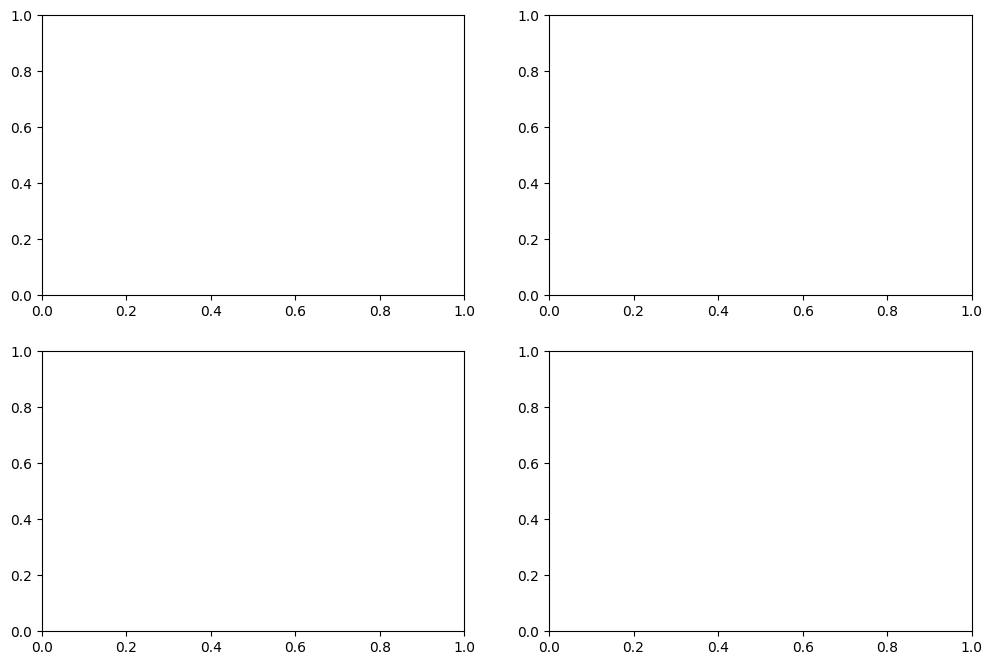

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
c = repo.named("churn_by_contract"); ax[0, 0].bar(c.Contract, c.churn_rate_pct, color="#2dd4bf"); ax[0, 0].set_title("Churn rate by contract (%)")
t = repo.named("churn_by_tenure"); ax[0, 1].bar(t.tenure_bucket, t.churn_rate_pct, color="#4cb5ff"); ax[0, 1].set_title("Churn rate by tenure (%)"); ax[0, 1].tick_params(axis="x", rotation=20)
roc = m["roc_curve"]; ax[1, 0].plot(roc["fpr"], roc["tpr"]); ax[1, 0].plot([0, 1], [0, 1], "--", color="grey"); ax[1, 0].set_title(f"ROC curve (AUC {m['test_at_tuned_threshold']['roc_auc']})")
fi = pd.DataFrame(m["feature_importance"]).iloc[::-1]; ax[1, 1].barh(fi.feature, fi.importance, color="#f5a524"); ax[1, 1].set_title("Permutation importance (drop in AUC)")
plt.tight_layout(); plt.show()

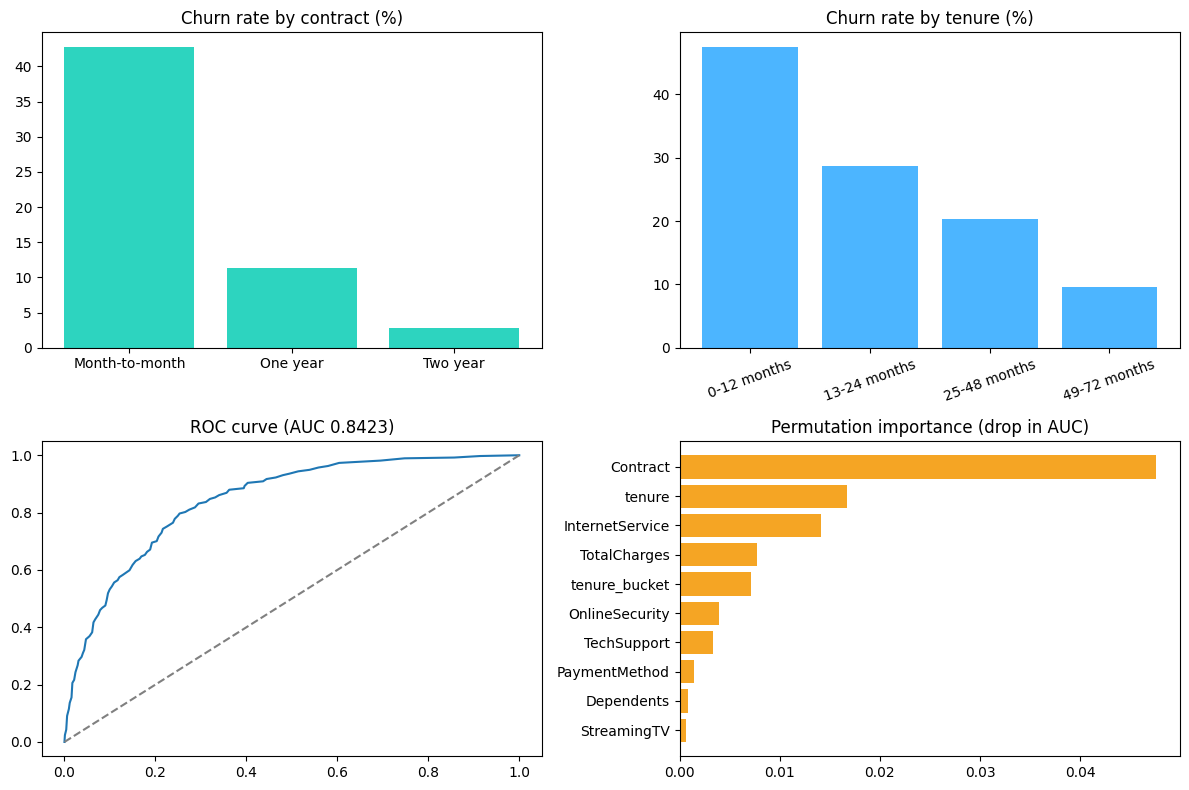

In [9]:
from churnlens.sql import SQLRepository
repo = SQLRepository()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
c = repo.named("churn_by_contract"); ax[0, 0].bar(c.Contract, c.churn_rate_pct, color="#2dd4bf"); ax[0, 0].set_title("Churn rate by contract (%)")
t = repo.named("churn_by_tenure"); ax[0, 1].bar(t.tenure_bucket, t.churn_rate_pct, color="#4cb5ff"); ax[0, 1].set_title("Churn rate by tenure (%)"); ax[0, 1].tick_params(axis="x", rotation=20)
roc = m["roc_curve"]; ax[1, 0].plot(roc["fpr"], roc["tpr"]); ax[1, 0].plot([0, 1], [0, 1], "--", color="grey"); ax[1, 0].set_title(f"ROC curve (AUC {m['test_at_tuned_threshold']['roc_auc']})")
fi = pd.DataFrame(m["feature_importance"]).iloc[::-1]; ax[1, 1].barh(fi.feature, fi.importance, color="#f5a524"); ax[1, 1].set_title("Permutation importance (drop in AUC)")
plt.tight_layout(); plt.show()

In [10]:
from churnlens.algorithms import TopK
from churnlens.modeling import export_for_bi
from churnlens.config import DB_PATH, EXPORT_PATH

current = repo.query("""SELECT c.customerID, c.Contract, c.tenure, c.MonthlyCharges, p.churn_probability
                        FROM customers c JOIN predictions p ON p.customerID = c.customerID WHERE c.churn_flag = 0""")
top = TopK(10).extend((row.churn_probability * row.MonthlyCharges, row) for row in current.itertuples(index=False))
print("Top 10 current customers by expected monthly revenue at risk (heap, O(n log k)):")
display(pd.DataFrame([{**r._asdict(), "expected_loss": round(s, 2)} for s, r in top.items()]))
display(repo.named("revenue_at_risk_by_contract"))
print("Power BI file:", export_for_bi(DB_PATH, EXPORT_PATH))

Top 10 current customers by expected monthly revenue at risk (heap, O(n log k)):


,customerID,Contract,tenure,MonthlyCharges,churn_probability,expected_loss
0,3292-PBZEJ,Month-to-month,11,111.40,0.8210,91.46
1,5150-ITWWB,Month-to-month,3,94.85,0.9447,89.60
2,7145-FEJWU,Month-to-month,12,105.30,0.8503,89.54
3,2081-VEYEH,Month-to-month,3,107.95,0.8279,89.37
4,5760-IFJOZ,Month-to-month,3,107.95,0.8274,89.32
5,4445-ZJNMU,Month-to-month,9,99.30,0.8940,88.77
6,5956-YHHRX,Month-to-month,21,104.35,0.8496,88.66
7,6734-GMPVK,Month-to-month,5,105.30,0.8364,88.07
8,9094-AZPHK,Month-to-month,15,100.15,0.8770,87.83
9,4132-KALRO,Month-to-month,4,100.85,0.8707,87.81


,Contract,customers,expected_monthly_revenue_at_risk
0,Month-to-month,2220,73939.40
1,One year,1307,20190.22
2,Two year,1647,9427.66


Power BI file: /content/exports/customers_for_powerbi.csv
